In [1]:
# Name: Isaack Newton Imbwagah
# Title: Explanatory Data Analysis
# Cyber Shujaa ID: CS-DA02 -25030

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")

In [3]:
# Load Titanic dataset
df = pd.read_csv('/kaggle/input/titanic/train.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# Shape of the data set(rows, columns)
print("Dataset shape:", df.shape)
# Column names
print("Columns:", df.columns)


Dataset shape: (891, 12)
Columns: Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [5]:
# Info datatypes # non null values
print("Dataset info")
df.info

Dataset info


<bound method DataFrame.info of      PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                   

In [6]:
# Summary statistics for numerical and categorical columns
df.describe(include='all')


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,B96 B98,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [7]:
# Handle missing values and outliers
print("Missing values per column:", df.isnull().sum())

Missing values per column: PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [8]:
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.drop(columns=['Cabin'], inplace=True)


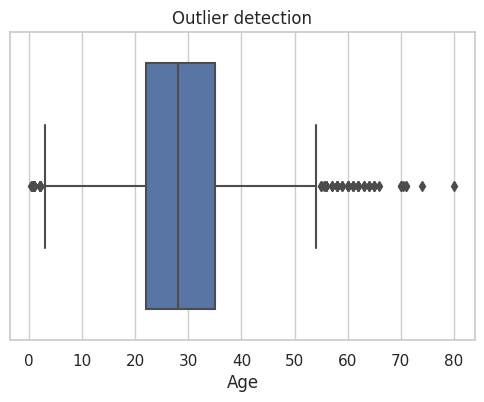

In [9]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df["Age"])
plt.title("Outlier detection")
plt.show()


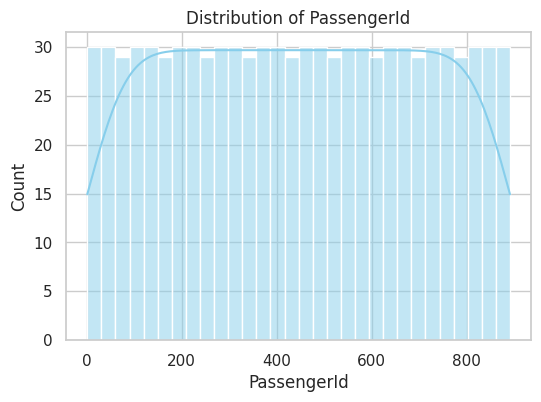

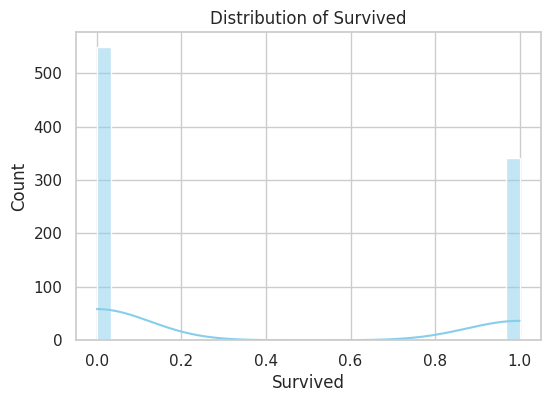

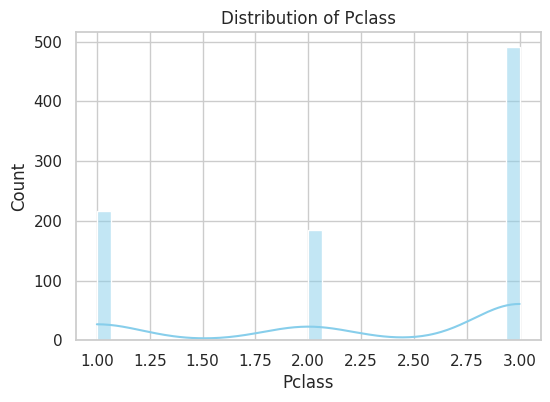

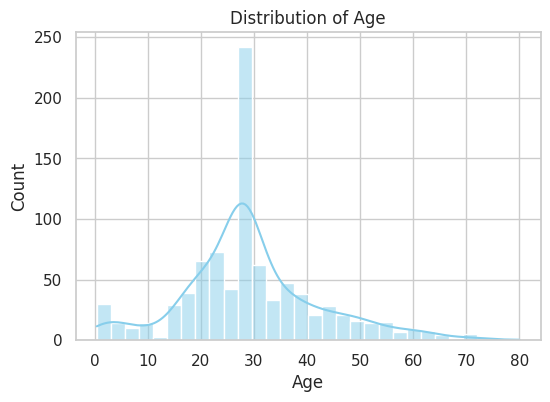

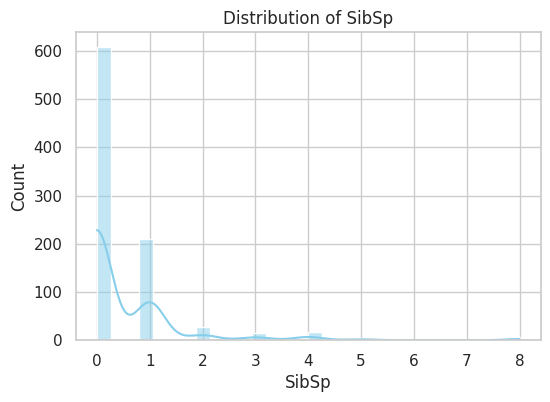

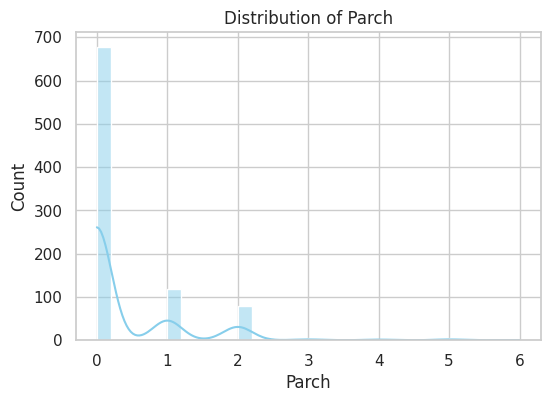

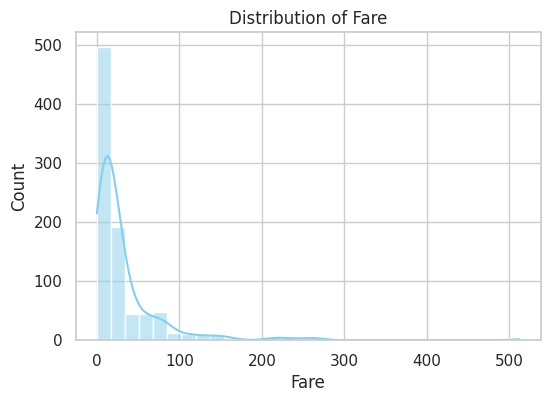

In [10]:
# Univariate Analysis - Numerical
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f"Distribution of {col}")
    plt.show()

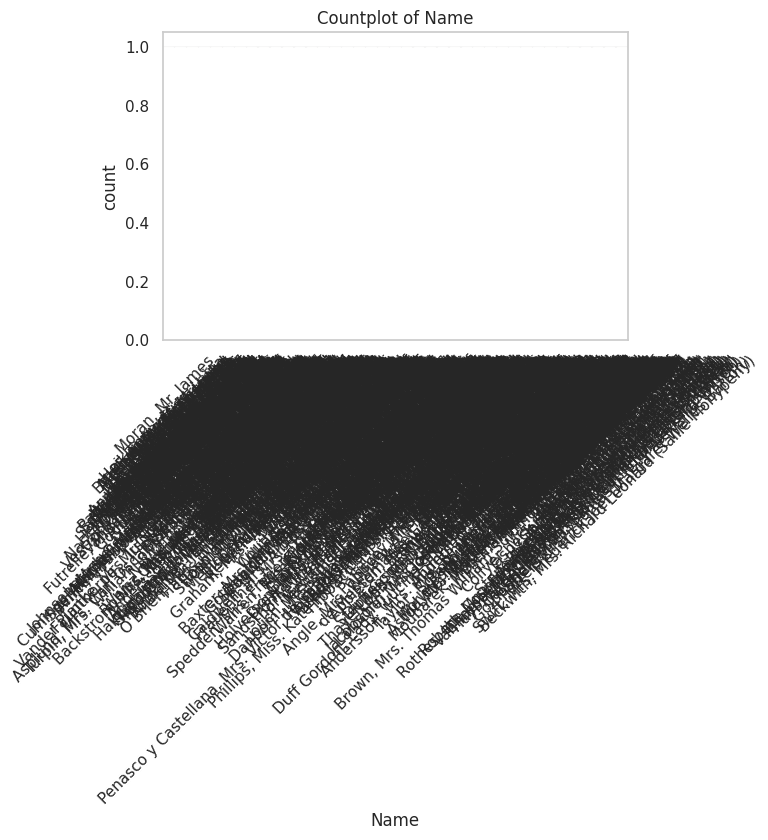

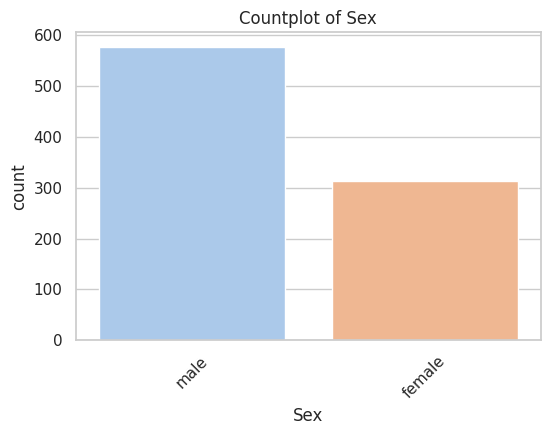

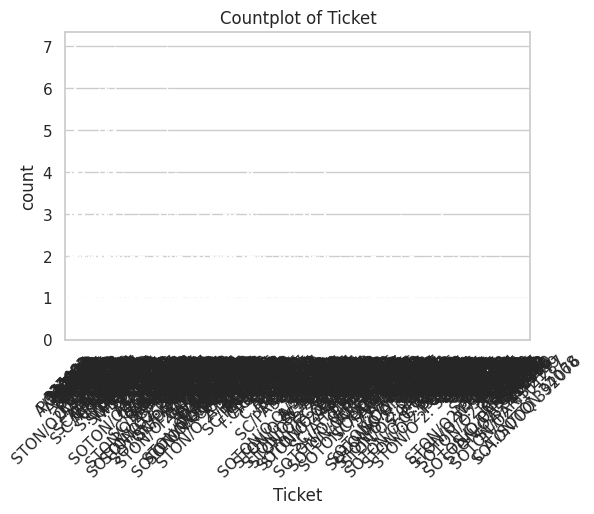

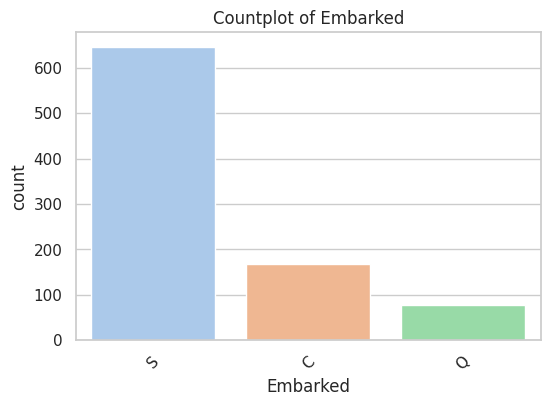

In [11]:
# Univariate Analysis - Categorical
cat_cols = df.select_dtypes(include=['object', 'category']).columns

for col in cat_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=df[col], palette='pastel')
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=45)
    plt.show()

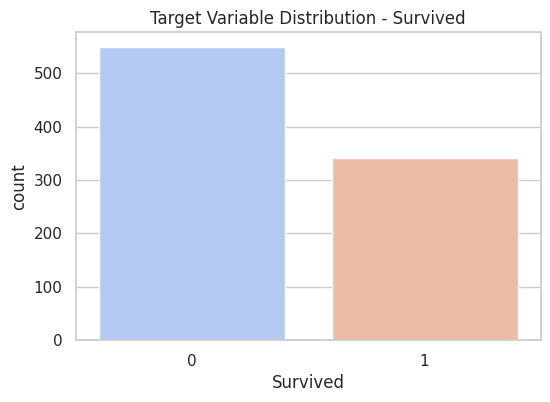


Survival Rate Breakdown:
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=df, palette='coolwarm')
plt.title("Target Variable Distribution - Survived")
plt.show()

print("\nSurvival Rate Breakdown:")
print(df['Survived'].value_counts(normalize=True) * 100)


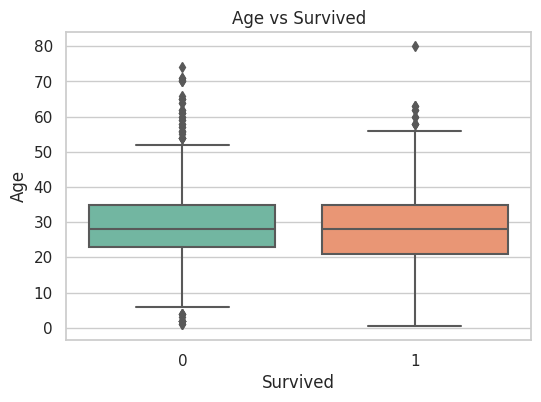

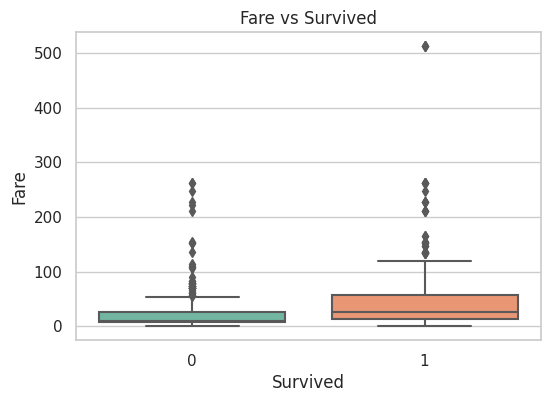

In [13]:
# Numerical vs Target
for col in ['Age', 'Fare']:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='Survived', y=col, data=df, palette='Set2')
    plt.title(f"{col} vs Survived")
    plt.show()

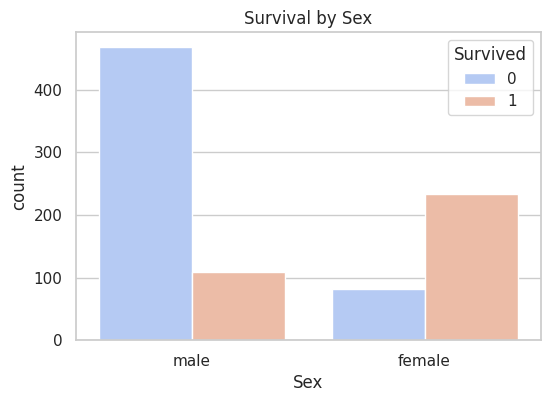

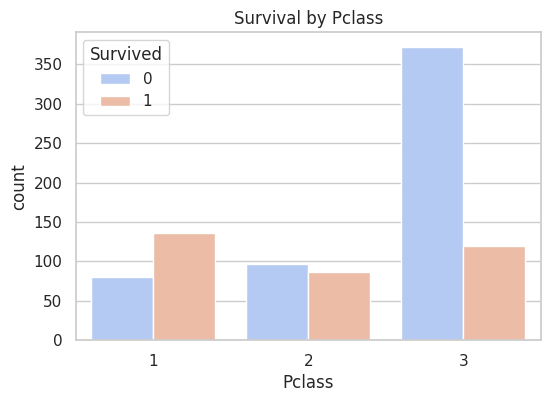

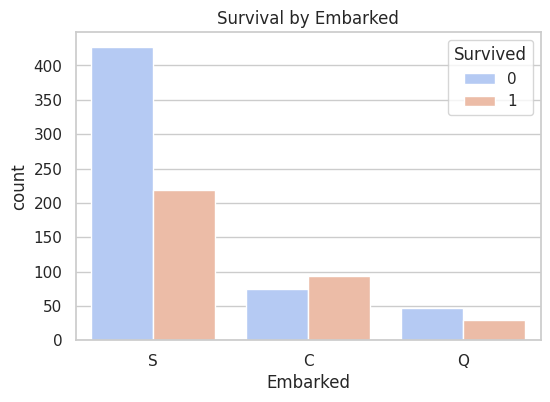

In [14]:
# Categorical vs Target
for col in ['Sex', 'Pclass', 'Embarked']:
    plt.figure(figsize=(6, 4))
    sns.countplot(x=col, hue='Survived', data=df, palette='coolwarm')
    plt.title(f"Survival by {col}")
    plt.show()

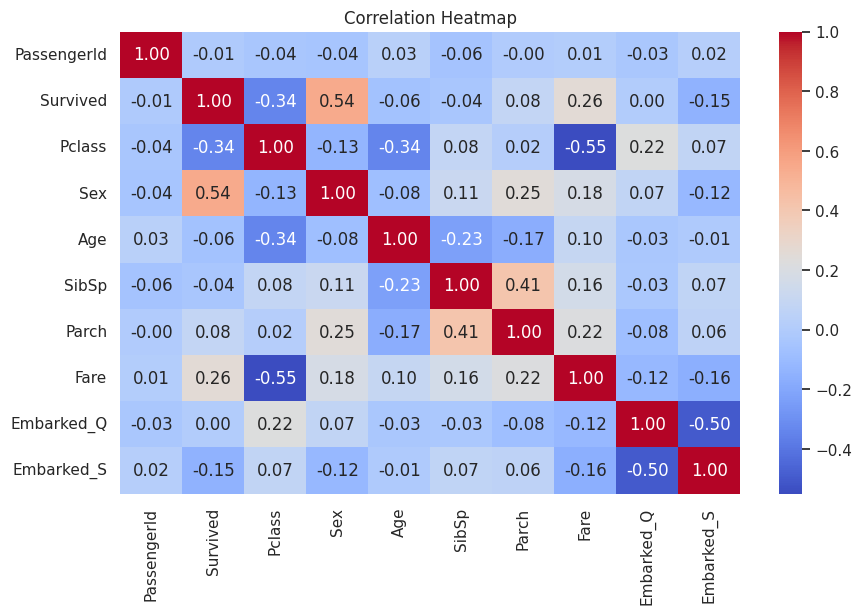

In [15]:
# Encode categorical vars for correlation
df_encoded = df.copy()
df_encoded['Sex'] = df_encoded['Sex'].map({'male': 0, 'female': 1})
df_encoded = pd.get_dummies(df_encoded, columns=['Embarked'], drop_first=True)

# Correlation Matrix
corr = df_encoded.corr(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


In [16]:
target = 'Survived'
corr_target = corr[target].sort_values(ascending=False)
print("Correlation of features with target variable:\n")
print(corr_target)


Correlation of features with target variable:

Survived       1.000000
Sex            0.543351
Fare           0.257307
Parch          0.081629
Embarked_Q     0.003650
PassengerId   -0.005007
SibSp         -0.035322
Age           -0.064910
Embarked_S    -0.149683
Pclass        -0.338481
Name: Survived, dtype: float64


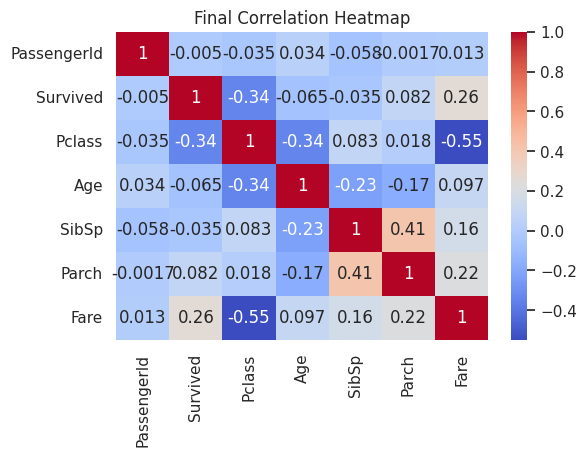

In [17]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Final Correlation Heatmap")
plt.show()


In [18]:
df.to_csv("titanic_cleaned.csv", index=False)
from IPython.display import FileLink
FileLink(r'titanic_cleaned.csv')


/kaggle/working/titanic_cleaned.csv